In [14]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt




def gather_results(results_folder,
                   epochs = None, classes = None, percents = None, runs = None, methods = None,
                   base = True, retrain = True):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            all_subdirs.append(os.path.join(root, d))
            
    if epochs is not None:
        epoch_dirs = [d for d in all_subdirs if "epoch" in d]
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        dirs_to_remove = [d for d in epoch_dirs if not re.search(pattern, d)]
        all_subdirs = [d for d in all_subdirs if d not in dirs_to_remove]

    if not base:
        all_subdirs = [d for d in all_subdirs if "base" not in d]

    if not retrain:
        all_subdirs = [d for d in all_subdirs if "retrain" not in d]

    if methods is not None:
        filtered = []
        for d in all_subdirs:
            d_norm = d.replace('\\', '/')
            if re.search(r'/run_\d+/', d_norm):
                # unlearn method dir — keep only if method name is a path component
                parts = d_norm.split('/')
                if any(p in methods for p in parts):
                    filtered.append(d)
            else:
                # base/retrain dirs — controlled by their own flags, not methods
                filtered.append(d)
        all_subdirs = filtered

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # remove the config json if it exists
        file_paths = [f for f in file_paths if "config" not in f]
        
        # remove any unnecessary classes, percents, runs
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if percents is not None:
            pattern = rf"percent_({'|'.join(map(str, percents))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if runs is not None:
            pattern = rf"run_({'|'.join(map(str, runs))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            continue
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            
            # add class if none
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match

            # add percent if none
            match = re.search(r'percent_(\d+)', f)
            if match:
                data['percent'] = int(match.group(1))
            else:
                data['percent'] = -99  # default value if no match

            # add epoch if none
            match = re.search(r'base', f)
            if match:
                data['epoch'] = -99

            match = re.search(r'retrain', f)
            if match:
                data['epoch'] = -98

            # add run if none
            match = re.search(r'run_(\d+)', f)
            if match:
                data['run'] = int(match.group(1))
            else:
                data['run'] = -99  # default value if no match

            # add method from path structure (run_N/METHOD/epoch_N)
            f_norm = f.replace('\\', '/')
            match = re.search(r'/run_\d+/([^/]+)/epoch', f_norm)
            if match:
                data['method'] = match.group(1)
            elif '/base/' in f_norm:
                data['method'] = 'base'
            elif '/retrain/' in f_norm:
                data['method'] = 'retrain'
            else:
                data['method'] = 'unknown'

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    if not all_results:
        raise ValueError("No results - check settings")
    final_df = pd.concat(all_results, axis=0)


    if "MIA" in final_df.columns:

        expanded_MIA = pd.json_normalize(final_df['MIA'])

        # json_normalize resets the index, so you MUST align it with your original dataframe
        expanded_MIA.index = final_df.index

        # Optional prefixing
        expanded_MIA = expanded_MIA.add_prefix('MIA_')

        # 2. Drop the original nested column and concatenate
        final_df = pd.concat([final_df.drop('MIA', axis=1), expanded_MIA], axis=1)

    return final_df


def results_scatterplot(final_df, x_metric, y_metric, 
                        color_by = "epoch", 
                        base_color = "black", retain_color = "purple"
                        ):

    
    # set up colors — use key=str to safely sort mixed-type columns (e.g. method strings)
    unique_vals = sorted(final_df[color_by].unique(), key=str)
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for val in unique_vals:
        if val == -99 or val == "base":
            palette_dict[val] = base_color
        elif val == -98 or val == "retrain":
            palette_dict[val] = retain_color
        else:
            # Use modulo to cycle through tab20 if you have more than 20 values
            palette_dict[val] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    # plot
    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=palette_dict,  # Use the mapping dictionary here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    # Replace numeric sentinels with readable labels
    new_labels = ["base" if label in ("-99", "-99.0") else "retrain" if label in ("-98", "-98.0") else label for label in labels]
    plt.legend(title=color_by.capitalize(), handles = handles, labels = new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [15]:
results = gather_results("results/seed_3013")
results

,forget_loss,forget_acc,forget_entr,forget_m_entr,retain_loss,retain_acc,retain_entr,retain_m_entr,test_loss,test_acc,...,MIA_confidence_no_class.retain_test_member,MIA_confidence_no_class.forget_non_member,MIA_entropy_class.retain_test_member,MIA_entropy_class.forget_non_member,MIA_entropy_no_class.retain_test_member,MIA_entropy_no_class.forget_non_member,MIA_m_entropy_class.retain_test_member,MIA_m_entropy_class.forget_non_member,MIA_m_entropy_no_class.retain_test_member,MIA_m_entropy_no_class.forget_non_member
0,3.425825,38.46,6.12805,3.349758,0.148106,96.6,0.392133,0.122379,0.588941,86.19,...,0.956889,0.9980,0.951000,0.0,0.975111,0.9586,0.953556,0.0,0.963667,0.9956
0,3.071336,11.96,4.536897,3.007602,0.133523,96.76,0.306123,0.109277,0.567482,83.26,...,0.966000,0.9980,0.939333,0.0,0.947333,0.9848,0.952000,0.0,0.962667,0.9966
0,3.291669,4.34,4.078104,3.258473,0.138971,96.426667,0.296076,0.118962,0.591256,82.83,...,0.940333,1.0000,0.919111,0.0,0.953000,0.9866,0.937444,0.0,0.949889,1.0000
0,3.690629,1.92,3.711842,3.727137,0.125834,96.633333,0.243808,0.112162,0.640888,82.42,...,0.944222,1.0000,0.897889,0.0,0.924556,0.9900,0.926667,0.0,0.955667,1.0000
0,3.643125,2.9,3.61284,3.678095,0.133799,96.322222,0.249392,0.121439,0.643378,82.6,...,0.943667,1.0000,0.915444,0.0,0.966000,0.9710,0.937111,0.0,0.935333,1.0000
0,3.193789,40.82,6.053879,3.09406,0.157524,96.493333,0.408697,0.13083,0.568773,86.09,...,0.957778,0.9968,0.929667,0.0,0.960889,0.9756,0.941556,0.0,0.961333,0.9912
0,2.913513,7.96,3.675066,2.891044,0.130647,96.731111,0.290377,0.10422,0.547081,83.04,...,0.939333,0.9998,0.928222,0.0,0.961444,0.9734,0.938111,0.0,0.953556,0.9992
0,3.398075,1.66,2.922066,3.434837,0.144474,96.357778,0.294609,0.122814,0.609817,82.5,...,0.941000,1.0000,0.907667,0.0,0.949556,0.9866,0.948889,0.0,0.952556,1.0000
0,3.5056,2.4,2.684969,3.572105,0.126756,96.466667,0.220182,0.116376,0.62469,82.5,...,0.950000,1.0000,0.918444,0.0,0.880000,0.9944,0.930444,0.0,0.945889,1.0000
0,3.853114,0.94,2.573212,3.944275,0.131511,96.415556,0.229721,0.118789,0.657501,82.37,...,0.951778,1.0000,0.908111,0.0,0.882556,0.9950,0.931333,0.0,0.947667,1.0000


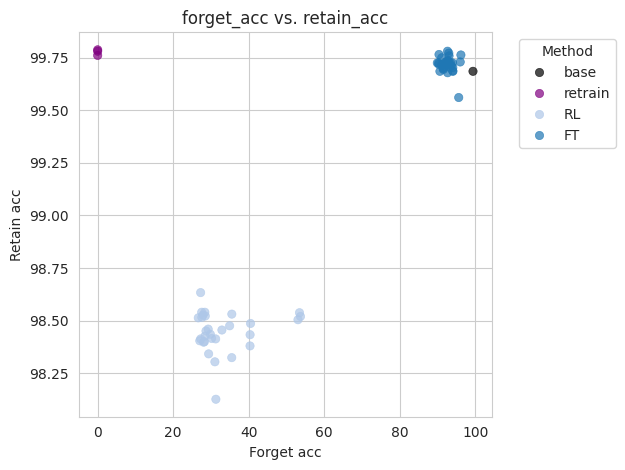

In [29]:
results = gather_results("results/seed_6", base=True, retrain=True) 
                        #  epochs = [-99, 0, 1, 2, 3, 4, 5, 6])
results_scatterplot(
    results, 
    x_metric = "forget_acc", y_metric = "retain_acc", 
    color_by = "method"
    )